In [52]:
import pandas as pd

df=pd.read_csv('../data/processed/sample_70k.csv')

df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_words,q2_words,common_words
0,281827,401637,401638,The twins (Adarsh and Anupam) were born in May...,"Twins (Adarsh and Anupam) were born in May, bu...",1,98,95,18,17,14
1,119174,193562,193563,Why can't I bare to watch someone being humili...,How can you prove mean lifetime formula in rad...,0,129,61,22,10,0
2,18341,34756,2929,My questions haven't changed. Why are they now...,What happens to a question on Quora if it is m...,1,83,83,13,15,4
3,259132,374863,374864,"Can anyone tell the program for sequence 4,6,1...",What are the next three numbers in this series?,0,67,47,8,9,1
4,208109,312009,201015,If the civil war occurred today who would win?,If there was another US Civil War (North vs So...,1,46,78,9,16,6


In [53]:
df.shape

(74242, 11)

### making it lowercase

In [54]:
def lower_text(text):
    return str(text).lower()

In [55]:
df['question1']=df['question1'].apply(lower_text)
df['question2']=df['question2'].apply(lower_text)

In [56]:
df[['question1','question2']].head()

,question1,question2
0,the twins (adarsh and anupam) were born in may...,"twins (adarsh and anupam) were born in may, bu..."
1,why can't i bare to watch someone being humili...,how can you prove mean lifetime formula in rad...
2,my questions haven't changed. why are they now...,what happens to a question on quora if it is m...
3,"can anyone tell the program for sequence 4,6,1...",what are the next three numbers in this series?
4,if the civil war occurred today who would win?,if there was another us civil war (north vs so...


# Stemming

In [57]:
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

In [58]:
def stem_text(text):
    return " ".join([stemmer.stem(word) for word in text.split()])

In [59]:
df['question1'] = df['question1'].apply(stem_text)
df['question2'] = df['question2'].apply(stem_text)

### Remove Punctuation

In [60]:
import re

def remove_punctuation(text):
    return re.sub(r'[^\w\s]',"",text)


    #syntax re.sub(pattern, replacement, string)

In [61]:
df['question1']=df['question1'].apply(remove_punctuation)
df['question2']=df['question2'].apply(remove_punctuation)

### Total Unique words

In [62]:
def total_words(q1,q2):
    w1=set(str(q1).split())
    w2=set(str(q2).split())

    return len(w1.union(w2))

In [63]:
df['total_unique_words']=df.apply(
    lambda row:
    total_words(
        row['question1'],
        row['question2']
    ),
    axis=1
    
)

In [64]:
df['word_share']=(
    df['common_words']/df['total_unique_words']
)

### Length differnce

In [65]:
df['len_diff']=abs(df['q1_len']-df['q2_len'])

## Visualisation


minimum characters  1
maximum characters 430


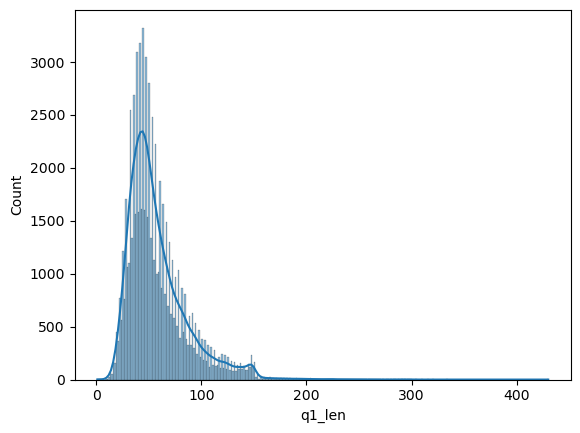

In [18]:
import seaborn as sns
sns.histplot(df['q1_len'],kde=True)
print('minimum characters ',df['q1_len'].min())
print('maximum characters',df['q1_len'].max())



minimum characters 1
maximum characters 1151
average num of characters 58


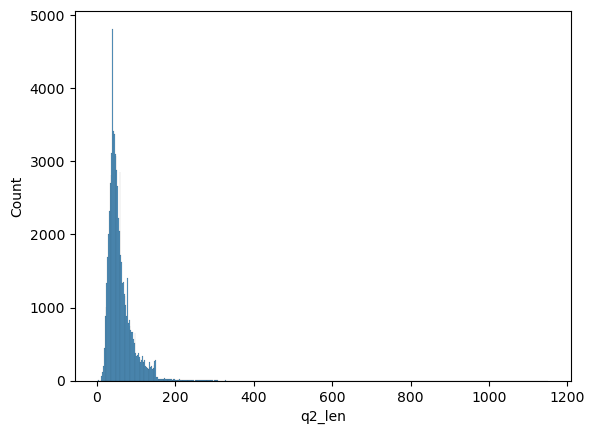

In [19]:
sns.histplot(df['q2_len'])
print('minimum characters',df['q2_len'].min())
print('maximum characters',df['q2_len'].max())
print('average num of characters',int(df['q2_len'].mean()))


minimum no of words in q1 1
maximum no of words in q1 80
average num of words 10


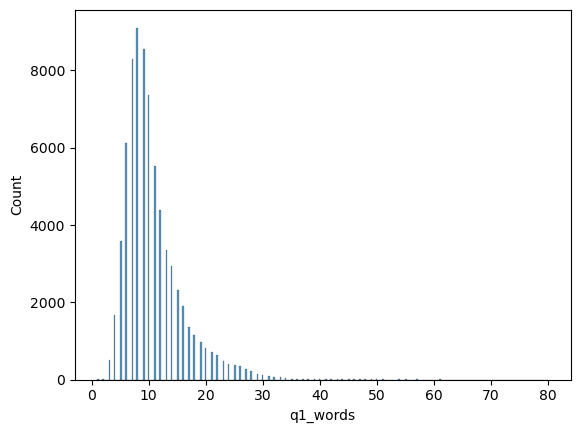

In [20]:
sns.histplot(df['q1_words'])
print("minimum no of words in q1",df['q1_words'].min())
print("maximum no of words in q1",df['q1_words'].max())
print('average num of words',int(df['q1_words'].mean()))

minimum no of words in q2 1
maximum no of words in q2 237
average num of words 10


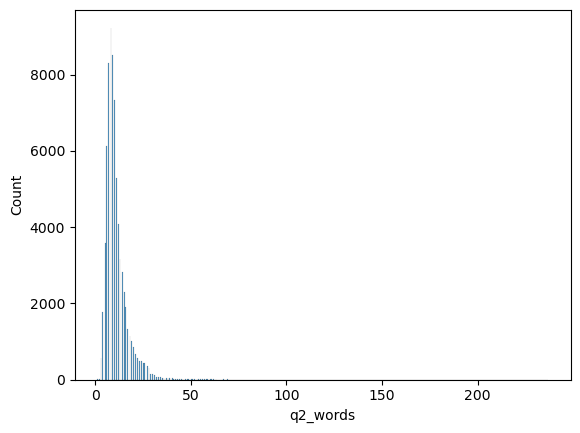

In [21]:
sns.histplot(df['q2_words'])
print("minimum no of words in q2",df['q2_words'].min())
print("maximum no of words in q2",df['q2_words'].max())
print('average num of words',int(df['q2_words'].mean()))

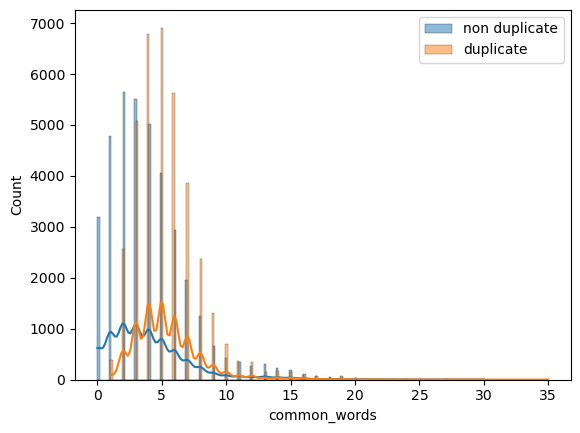

In [22]:
import matplotlib.pyplot as plt

sns.histplot(df[df['is_duplicate']==0]['common_words'],label='non duplicate',kde=True)
sns.histplot(df[df['is_duplicate']==1]['common_words'],label='duplicate',kde=True)

plt.legend()
plt.show()

In [23]:
df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_words,q2_words,common_words,total_unique_words,word_share,len_diff
0,281827,401637,401638,the twin adarsh and anupam were born in may bu...,twin adarsh and anupam were born in may but th...,1,98,95,18,17,14,17,0.823529,3
1,119174,193562,193563,whi cant i bare to watch someon be humili irlm...,how can you prove mean lifetim formula in radi...,0,129,61,22,10,0,31,0.000000,68
2,18341,34756,2929,my question havent changed whi are they now be...,what happen to a question on quora if it is ma...,1,83,83,13,15,4,23,0.173913,0
3,259132,374863,374864,can anyon tell the program for sequenc 4612183...,what are the next three number in thi series,0,67,47,8,9,1,16,0.062500,20
4,208109,312009,201015,if the civil war occur today who would win,if there wa anoth us civil war north vs south ...,1,46,78,9,16,6,19,0.315789,32


C:\Users\INDIA\AppData\Local\Temp\ipykernel_18712\1607306682.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[df['is_duplicate'] == 0]['word_share'],label='non duplicate')
C:\Users\INDIA\AppData\Local\Temp\ipykernel_18712\1607306682.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[df

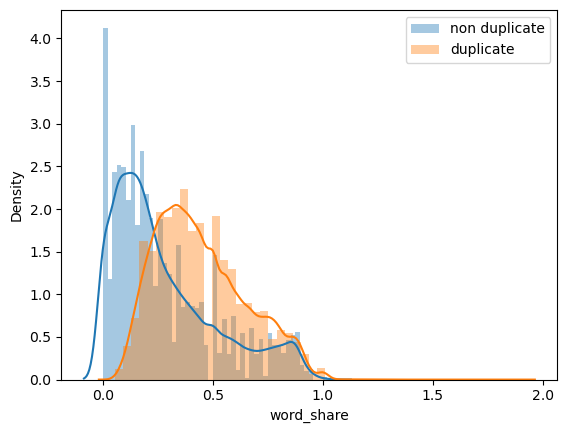

In [24]:
# word share
sns.distplot(df[df['is_duplicate'] == 0]['word_share'],label='non duplicate')
sns.distplot(df[df['is_duplicate'] == 1]['word_share'],label='duplicate')
plt.legend()
plt.show()

In [25]:
!pip install fuzzywuzzy

Defaulting to user installation because normal site-packages is not writeable


In [66]:
from fuzzywuzzy import fuzz

df['fuzz_ratio']=df.apply(
    lambda row:
    fuzz.QRatio(
        row['question1'],
        row['question2']
    ),
    axis=1
)

In [67]:
df['partial_ratio'] = df.apply(
    lambda row:
    fuzz.partial_ratio(
        row['question1'],
        row['question2']
    ),
    axis=1
)

# TF-IDF

In [68]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [69]:
#combine text

questions=list(df['question1'])+list(df['question2'])

In [70]:
#create vectorizer

tfidf=TfidfVectorizer(
    max_features=20000,
    ngram_range=(1,2),   # VERY IMPORTANT
    stop_words='english'
)

In [71]:
tfidf.fit(questions)

,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None
,analyzer,'word'
,stop_words,'english'
,token_pattern,'(?u)\\b\\w\\w+\\b'
,ngram_range,"(1, ...)"


In [72]:
q1_tfidf=tfidf.transform(df['question1'])
q2_tfidf=tfidf.transform(df['question2'])

In [74]:
#calculate sine cosine similarity
from sklearn.metrics.pairwise import cosine_similarity
tfidf_cosine_similarity=[]

from sklearn.metrics.pairwise import cosine_similarity

tfidf_cosine_similarity = []

for i in range(q1_tfidf.shape[0]):
    sim = cosine_similarity(
        q1_tfidf[i],
        q2_tfidf[i]
    )[0][0]
    tfidf_cosine_similarity.append(sim)

df['tfidf_cosine_similarity'] = tfidf_cosine_similarity

In [75]:
df.groupby('is_duplicate')['tfidf_cosine_similarity'].mean()

is_duplicate
0    0.416001
1    0.602708
Name: tfidf_cosine_similarity, dtype: float64

In [76]:
df.to_csv(
    '../data/processed/final_features.csv',
    index=False
)

In [77]:
df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_words,q2_words,common_words,total_unique_words,word_share,len_diff,fuzz_ratio,partial_ratio,tfidf_cosine_similarity
0,281827,401637,401638,the twin adarsh and anupam were born in may bu...,twin adarsh and anupam were born in may but th...,1,98,95,18,17,14,17,0.823529,3,98,100,1.000000
1,119174,193562,193563,whi cant i bare to watch someon be humili irlm...,how can you prove mean lifetim formula in radi...,0,129,61,22,10,0,31,0.000000,68,10,32,0.000000
2,18341,34756,2929,my question havent changed whi are they now be...,what happen to a question on quora if it is ma...,1,83,83,13,15,4,23,0.173913,0,53,59,0.481669
3,259132,374863,374864,can anyon tell the program for sequenc 4612183...,what are the next three number in thi series,0,67,47,8,9,1,16,0.062500,20,33,34,0.000000
4,208109,312009,201015,if the civil war occur today who would win,if there wa anoth us civil war north vs south ...,1,46,78,9,16,6,19,0.315789,32,61,50,0.455399


# word2Vec 

In [41]:
!pip install gensim

Defaulting to user installation because normal site-packages is not writeable


In [42]:
sentences = (
    df['question1'].astype(str).apply(lambda x: x.split()).tolist() +
    df['question2'].astype(str).apply(lambda x: x.split()).tolist()
)

In [43]:
#training word to vec model

from gensim.models import Word2Vec

w2v_model=Word2Vec(
    sentences,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4
)

In [44]:
#convert sentence to vectors

import numpy as np

def get_vector(text):
    words=text.split()
    vectors=[]

    for word in words:
        if word in w2v_model.wv:
            vectors.append(w2v_model.wv[word])

    if len(vectors)==0:
        return np.zeros(100)

    return np.mean(vectors,axis=0)

In [45]:
# compute similaritu

def w2v_similarity(q1,q2):
    v1=get_vector(q1)
    v2=get_vector(q2)

    return cosine_similarity([v1],[v2])[0][0]

In [46]:
df['w2v_similarity'] = df.apply(
    lambda row: w2v_similarity(
        row['question1'],
        row['question2']
    ),
    axis=1
)

In [47]:
df.groupby('is_duplicate')['w2v_similarity'].mean()

is_duplicate
0    0.758118
1    0.865501
Name: w2v_similarity, dtype: float64

In [48]:
df.to_csv(
    '../data/processed/final_featuresWord2vec.csv',
    index=False
)

In [49]:
df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_words,q2_words,common_words,total_unique_words,word_share,len_diff,fuzz_ratio,partial_ratio,tfidf_cosine_similarity,w2v_similarity
0,281827,401637,401638,the twin adarsh and anupam were born in may bu...,twin adarsh and anupam were born in may but th...,1,98,95,18,17,14,17,0.823529,3,98,100,0.996701,0.988647
1,119174,193562,193563,whi cant i bare to watch someon be humili irlm...,how can you prove mean lifetim formula in radi...,0,129,61,22,10,0,31,0.000000,68,10,32,0.000000,0.628725
2,18341,34756,2929,my question havent changed whi are they now be...,what happen to a question on quora if it is ma...,1,83,83,13,15,4,23,0.173913,0,53,59,0.432014,0.903858
3,259132,374863,374864,can anyon tell the program for sequenc 4612183...,what are the next three number in thi series,0,67,47,8,9,1,16,0.062500,20,33,34,0.016145,0.597106
4,208109,312009,201015,if the civil war occur today who would win,if there wa anoth us civil war north vs south ...,1,46,78,9,16,6,19,0.315789,32,61,50,0.447452,0.939977


# saving TF-idf and Word2vec

In [50]:
import pickle

with open('../models/tfidf_vectorizer.pkl','wb') as f:
    pickle.dump(tfidf,f)

print("TF-IDF vectorizer saved")

TF-IDF vectorizer saved


In [51]:
w2v_model.save('../models/w2v_model.model')

print("Word2Vec model saved")

Word2Vec model saved
